---
numbering: false
---

# 2.1: Lines in ℝ²

In [1]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import sys

_notes_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'myst.yml').exists())
if str(_notes_root) not in sys.path:
    sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly

BLUE, ORANGE, PINK = '#3d81f6', 'orange', '#d81a60'


def base2(xrange=(-5, 6), yrange=(-5, 5), width=700, height=580, tick=1):
    fig = style_plotly(go.Figure(), renderer='png')
    fig.update_layout(width=width, height=height, showlegend=False,
                      font=dict(size=17), margin=dict(l=55, r=30, t=30, b=50))
    fig.update_xaxes(title='x', range=xrange, dtick=tick, zeroline=True, zerolinewidth=1.5,
                     constrain='domain', scaleanchor='y', scaleratio=1)
    fig.update_yaxes(title='y', range=yrange, dtick=tick, zeroline=True, zerolinewidth=1.5,
                     constrain='domain')
    return fig


def line2(fig, start, end, color=BLUE, dash='solid', width=2):
    fig.add_trace(go.Scatter(x=[start[0], end[0]], y=[start[1], end[1]], mode='lines',
                            line=dict(color=color, width=width, dash=dash),
                            hoverinfo='skip', showlegend=False))


def label2(fig, xy, label, dx=0, dy=0):
    fig.add_annotation(x=float(xy[0])+dx, y=float(xy[1])+dy, text=label, showarrow=False,
                       font=dict(color='black', size=17))


def point2(fig, xy, label=None, dx=0.35, dy=0.35):
    fig.add_trace(go.Scatter(x=[xy[0]], y=[xy[1]], mode='markers',
                            marker=dict(color='black', size=7), hoverinfo='skip'))
    if label: label2(fig, xy, label, dx, dy)


def vec2(fig, end, label=None, color=BLUE, start=(0, 0), dx=0.25, dy=0.3, width=3):
    fig.add_annotation(x=float(end[0]), y=float(end[1]), ax=float(start[0]), ay=float(start[1]),
                       xref='x', yref='y', axref='x', ayref='y', showarrow=True,
                       text='', arrowhead=3, arrowsize=1.25, arrowwidth=width, arrowcolor=color)
    if label: label2(fig,end,label,dx,dy)


def square2(fig, corner, along, perp, size=0.3):
    corner=np.asarray(corner,dtype=float)
    u=np.asarray(along,dtype=float); u=u/np.linalg.norm(u)*size
    v=np.asarray(perp,dtype=float); v=v/np.linalg.norm(v)*size
    line2(fig,corner+u,corner+u+v,'gray',width=1.5)
    line2(fig,corner+v,corner+u+v,'gray',width=1.5)


def base3():
    fig=style_plotly(go.Figure(),renderer='plotly_mimetype')
    axis=dict(range=[-6,7],dtick=2,showbackground=True,showspikes=False)
    fig.update_layout(width=760,height=620,showlegend=False,font=dict(size=16),
                      margin=dict(l=0,r=0,t=15,b=0),
                      scene=dict(xaxis=dict(title='x',**axis),yaxis=dict(title='y',**axis),
                                 zaxis=dict(title='z',**axis),aspectmode='cube',
                                 camera=dict(eye=dict(x=1.6,y=-2.1,z=1.3))))
    for direction in np.eye(3):
        line3(fig,-6*direction,7*direction,'#9ca3af',width=2)
    return fig


def line3(fig,start,end,color=BLUE,width=5,dash='solid'):
    fig.add_trace(go.Scatter3d(x=[start[0],end[0]],y=[start[1],end[1]],z=[start[2],end[2]],
                              mode='lines',line=dict(color=color,width=width,dash=dash),
                              hoverinfo='skip',showlegend=False))


def vec3(fig,end,label,color=BLUE,start=(0,0,0),offset=(0.25,0.25,0.35)):
    start,end=np.asarray(start,float),np.asarray(end,float)
    direction=(end-start)/np.linalg.norm(end-start)
    line3(fig,start,end-0.15*direction,color,width=7)
    fig.add_trace(go.Cone(x=[end[0]],y=[end[1]],z=[end[2]],u=[direction[0]],v=[direction[1]],w=[direction[2]],
                         anchor='tip',sizemode='absolute',sizeref=0.45,colorscale=[[0,color],[1,color]],
                         showscale=False,hoverinfo='skip'))
    pos=end+offset
    fig.add_trace(go.Scatter3d(x=[pos[0]],y=[pos[1]],z=[pos[2]],mode='text',text=[label],
                              textfont=dict(color='black',size=16),hoverinfo='skip'))


def plane3(fig,normal,color=BLUE,opacity=0.24):
    # Solve n_x*x + n_y*y + n_z*z = 0 for y on a rectangular x,z mesh.
    x,z=np.meshgrid(np.linspace(-5,6,2),np.linspace(-5,6,2))
    n=np.asarray(normal,float)
    y=-(n[0]*x+n[2]*z)/n[1]
    fig.add_trace(go.Surface(x=x.tolist(),y=y.tolist(),z=z.tolist(),
                            colorscale=[[0,color],[1,color]],opacity=opacity,
                            showscale=False,hoverinfo='skip'))
    corners=np.array([[x[0,0],y[0,0],z[0,0]],[x[0,1],y[0,1],z[0,1]],
                      [x[1,1],y[1,1],z[1,1]],[x[1,0],y[1,0],z[1,0]]])
    for i in range(4): line3(fig,corners[i],corners[(i+1)%4],color,width=2)


In [Chapter 1.4](../ch01/01-04.ipynb), we drew the vector

$$
\vec v=\begin{bmatrix}3\\-1\end{bmatrix}
$$

along with $3\vec v$ and $-\tfrac12\vec v$. When drawn from the origin, all three arrows lie on the **same line**.

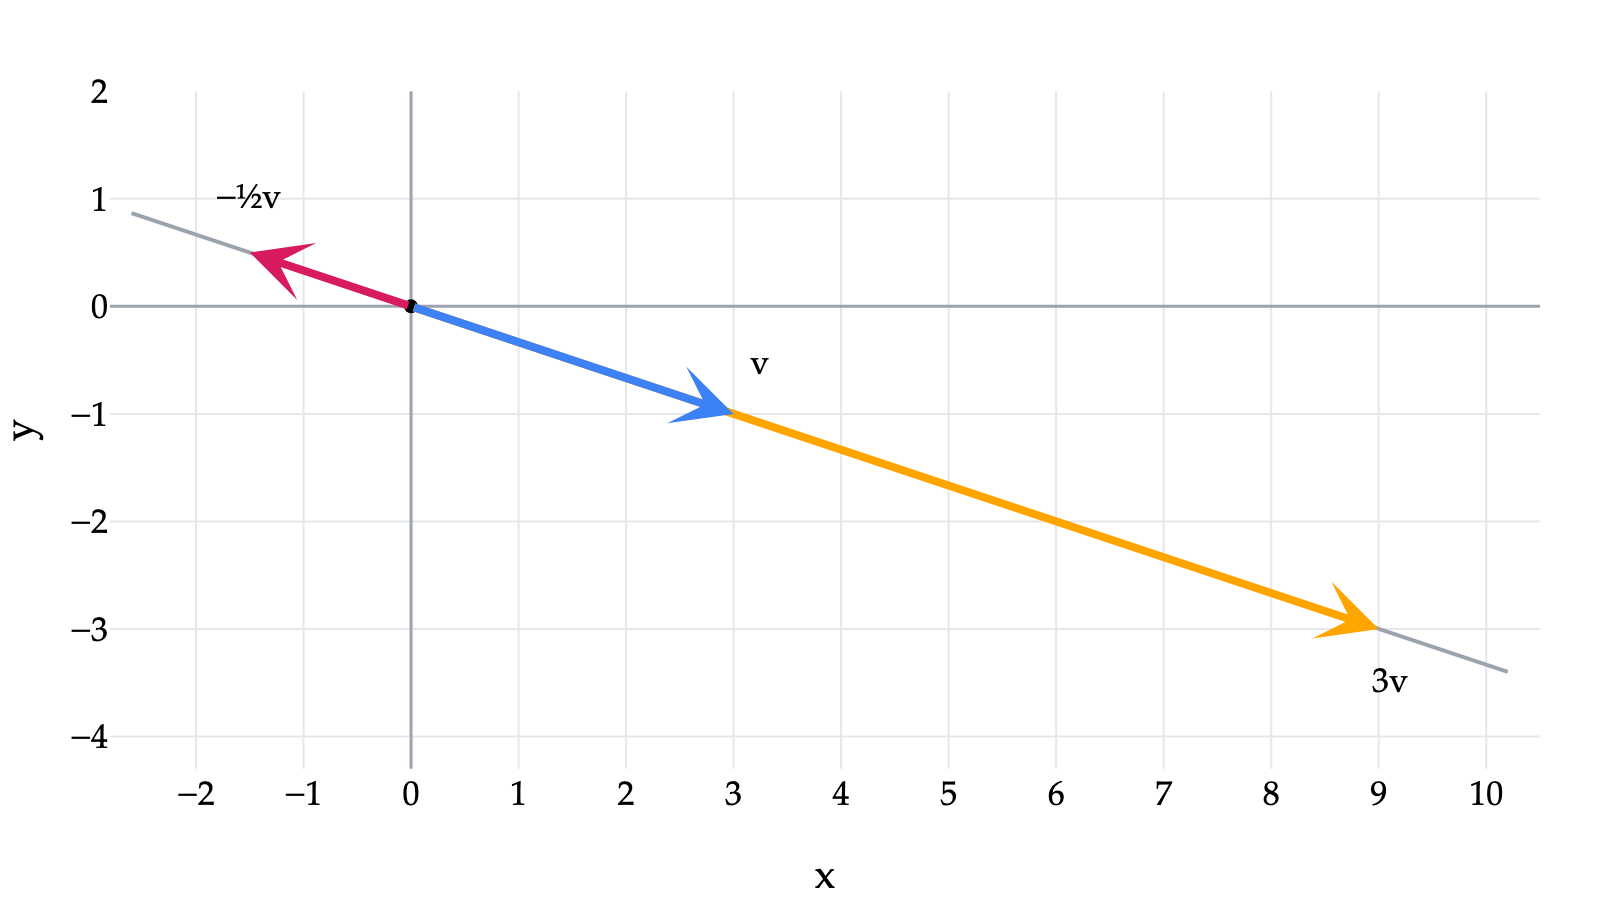

In [2]:
fig=base2((-2.8,10.5),(-4.3,2),width=800,height=450)
line2(fig,(-2.6,2.6/3),(10.2,-3.4),'#9ca3af')
vec2(fig,(9,-3),'3v',ORANGE,dx=0.1,dy=-0.5,width=4)
vec2(fig,(3,-1),'v',BLUE,dy=0.45,width=4)
vec2(fig,(-1.5,0.5),'−½v',PINK,dx=0,dy=0.5,width=4)
point2(fig,(0,0))
fig.show(scale=2)

The vector $\vec v=\begin{bmatrix}3\\-1\end{bmatrix}$ and its scalar multiples from Chapter 1.4 all lie on one line.

What if we drew **every** scalar multiple of $\vec v$? Positive multiples extend along one direction, negative multiples extend along the opposite direction, and $0\vec v$ gives the origin. Together, they fill the entire line!

In this section, we'll give this collection a name—the **span** of $\vec v$—and connect this vector description to a familiar line equation. Then we'll use orthogonality from [Chapter 1.6](../ch01/01-06.ipynb) to describe the same line using a perpendicular vector.

Let's start with another line, $3x-4y=0$, which we'll use throughout the section.

## Homogeneous and nonhomogeneous equations

A line in $\mathbb{R}^2$ is given algebraically by an equation $ax+by=c$, where $a$ and $b$ are not both zero.
The simplest lines to study are also those that contain the origin $(0,0)$.

$$
\ell:
\quad 
3x-4y=0.
$$

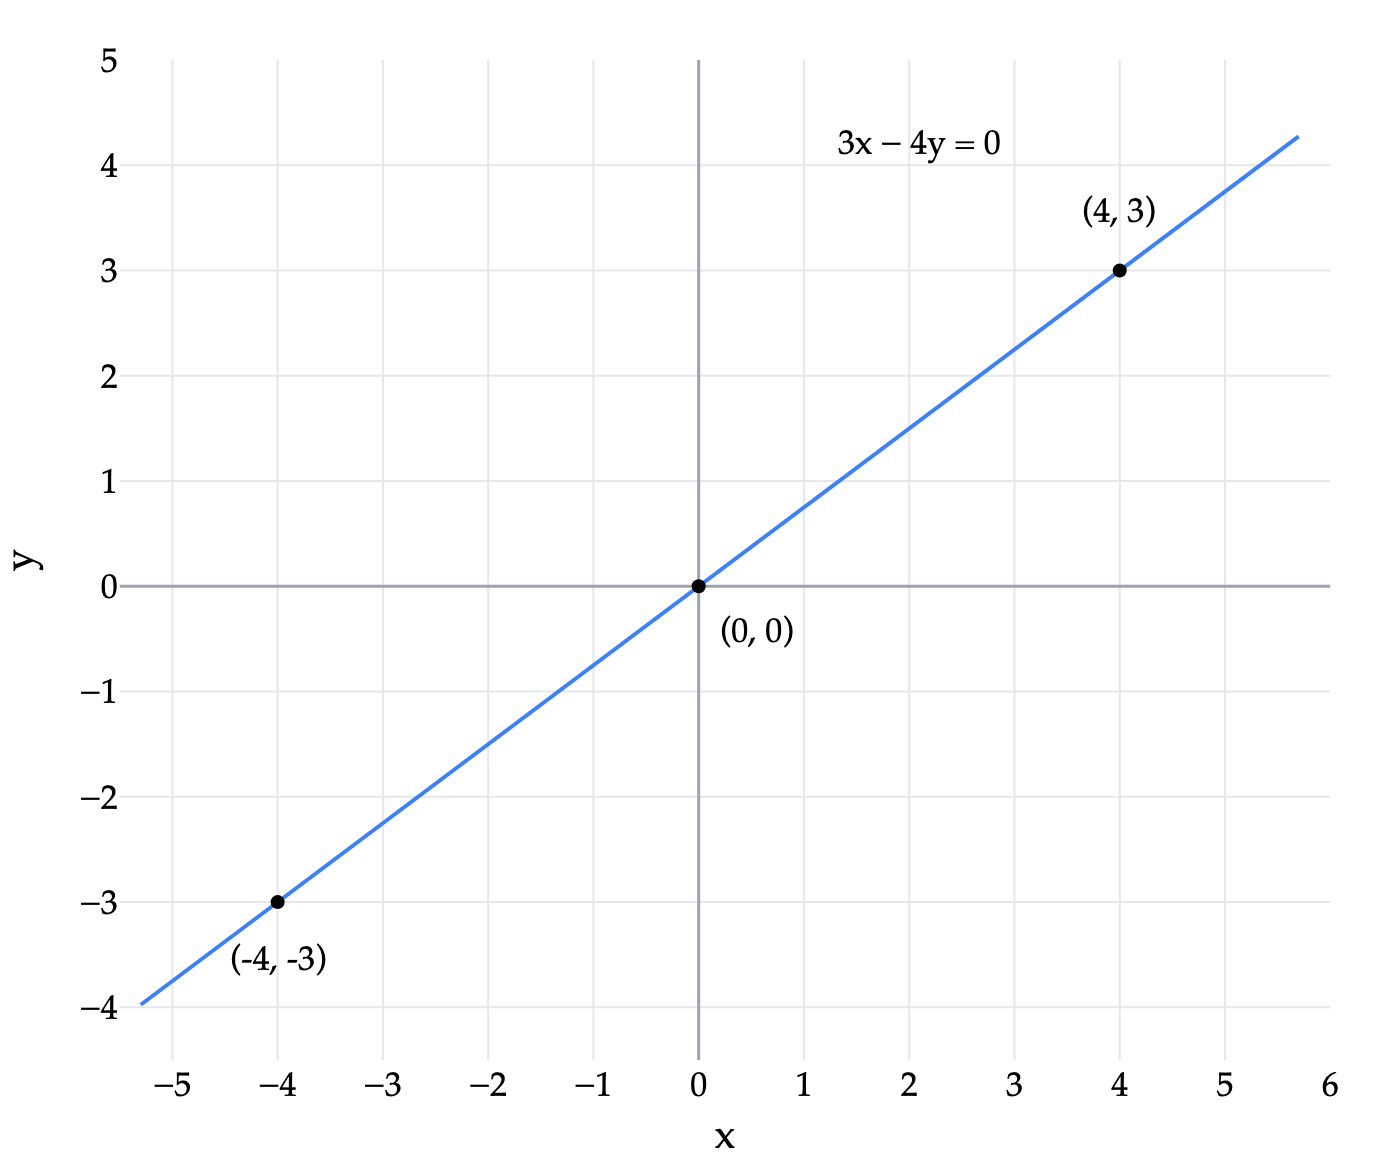

In [3]:
fig=base2((-5.5,6),(-4.5,5))
line2(fig,(-5.3,-3.975),(5.7,4.275))
for xy,dx,dy in [((0,0),0.55,-0.45),((4,3),0,0.55),((-4,-3),0,-0.55)]:
    point2(fig,xy,str(xy),dx,dy)
label2(fig,(2.1,4.2),'3x − 4y = 0')
fig.show(scale=2)

The line $3x-4y=0$, which passes through the origin.

**Remark.**

The $0$ on the right of the equation is what forces the line to go through
$(0,0)$. Such an equation is called homogeneous.

If one changes the $0$ to a nonzero number, then the line will not go through
the origin $(0,0)$.

$$
\qquad
3x-4y=7
\qquad
\longrightarrow
\qquad
\text{nonhomogeneous linear equation.}
$$

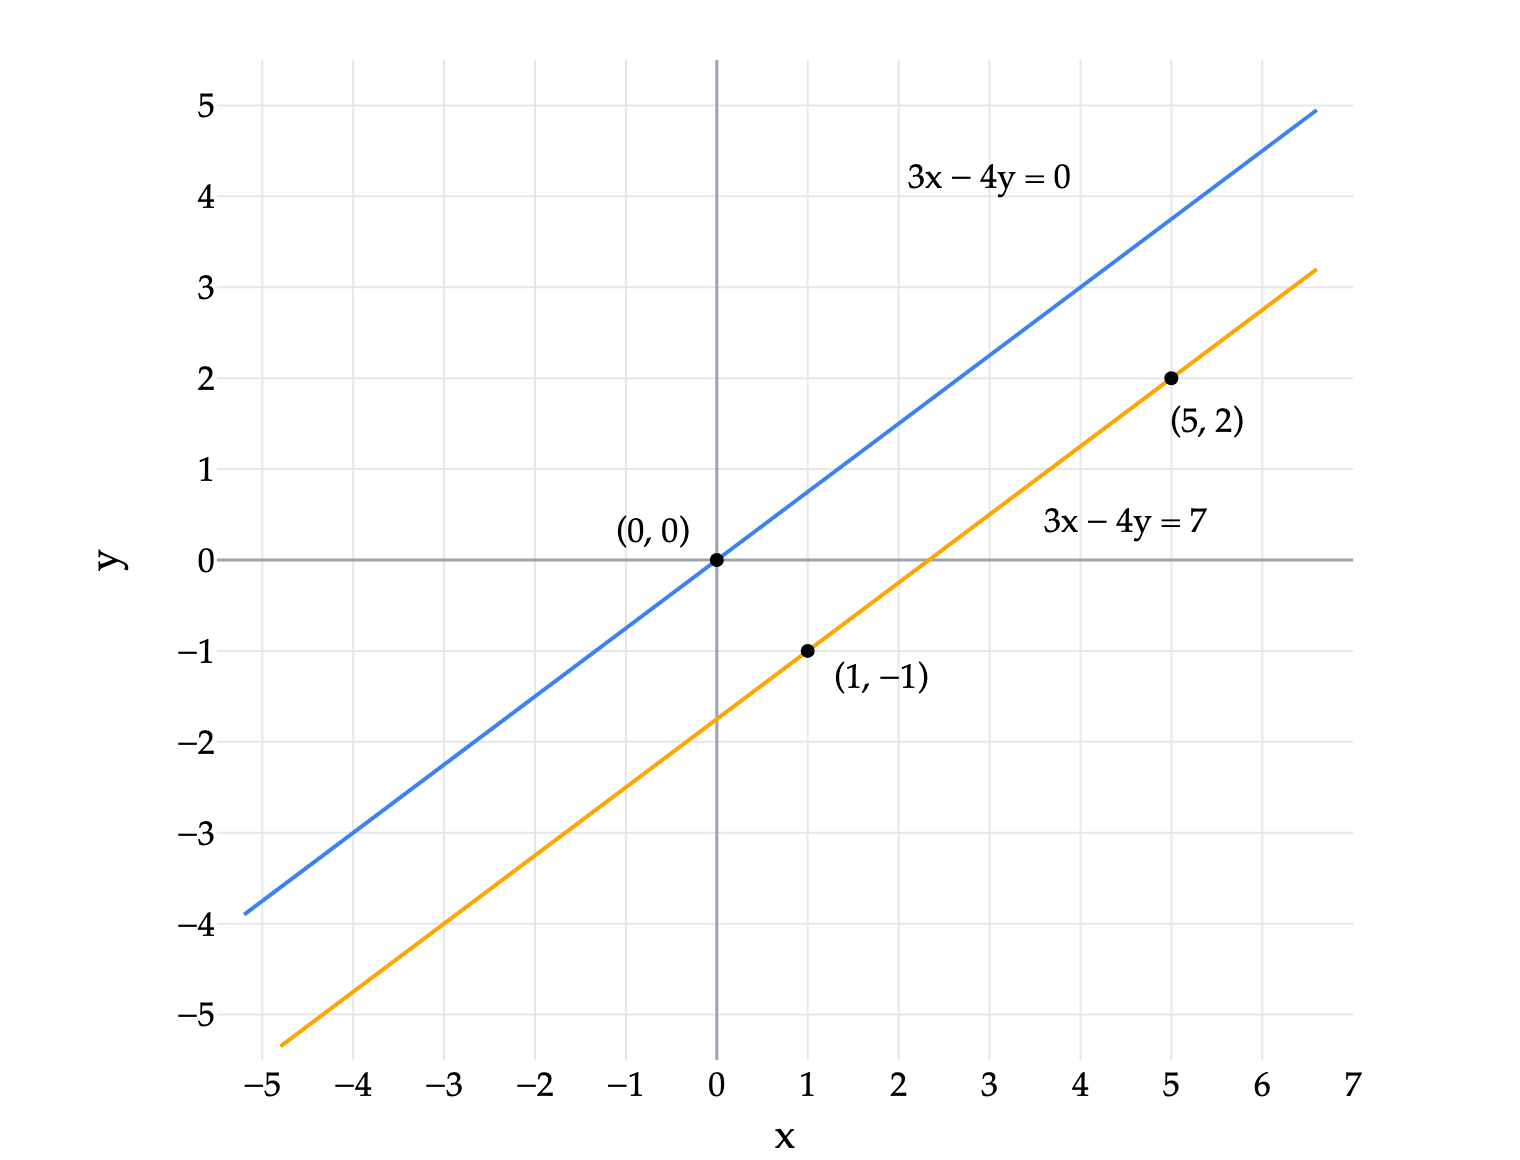

In [4]:
fig=base2((-5.5,7),(-5.5,5.5),width=760)
line2(fig,(-5.2,-3.9),(6.6,4.95))
line2(fig,(-4.8,-5.35),(6.6,3.2),ORANGE)
point2(fig,(0,0),'(0, 0)',dx=-0.7,dy=0.3)
point2(fig,(1,-1),'(1, −1)',dx=0.8,dy=-0.3)
point2(fig,(5,2),'(5, 2)',dx=0.4,dy=-0.5)
label2(fig,(3,4.2),'3x − 4y = 0')
label2(fig,(4.5,0.4),'3x − 4y = 7')
fig.show(scale=2)

Changing the right-hand side from $0$ to $7$ gives a parallel line.

We get in this way a line that is parallel to $3x-4y=0$.

By varying $c$, the equation

$$
3x-4y=c
$$

will give all possible lines in the plane that are parallel to the line $\ell$.

We'll first focus on the homogeneous case: lines through the origin.

## Lines as spans

The opening example suggests a second way to describe a line through the origin: give one nonzero vector along it and take all of its scalar multiples.

Let

$$
\vec v=
\begin{bmatrix}
4\\
3
\end{bmatrix}.
$$

The line $\ell$ can be described as all multiples of this vector.

Indeed, every point on the line is of the form $(4t,3t)$ for some scalar $t \in \mathbb{R}$. For example, we've plotted the vectors $\vec{v}$, $\frac{1}{2}\vec{v}$ and 
$-\frac{1}{2}\vec{v}$
in the figure below.  

:::{note} Key idea
We say $\ell$ is the span of the vector

$$
\vec{v} = \begin{bmatrix}
4\\
3
\end{bmatrix}.
$$

:::

For a nonzero vector $\vec v$, its **span** is the set of all scalar multiples:

$$
\operatorname{span}(\vec v)=\{t\vec v:t\in\mathbb R\}.
$$

Allowing every real value of $t$ gives the entire line, including the origin when $t=0$.

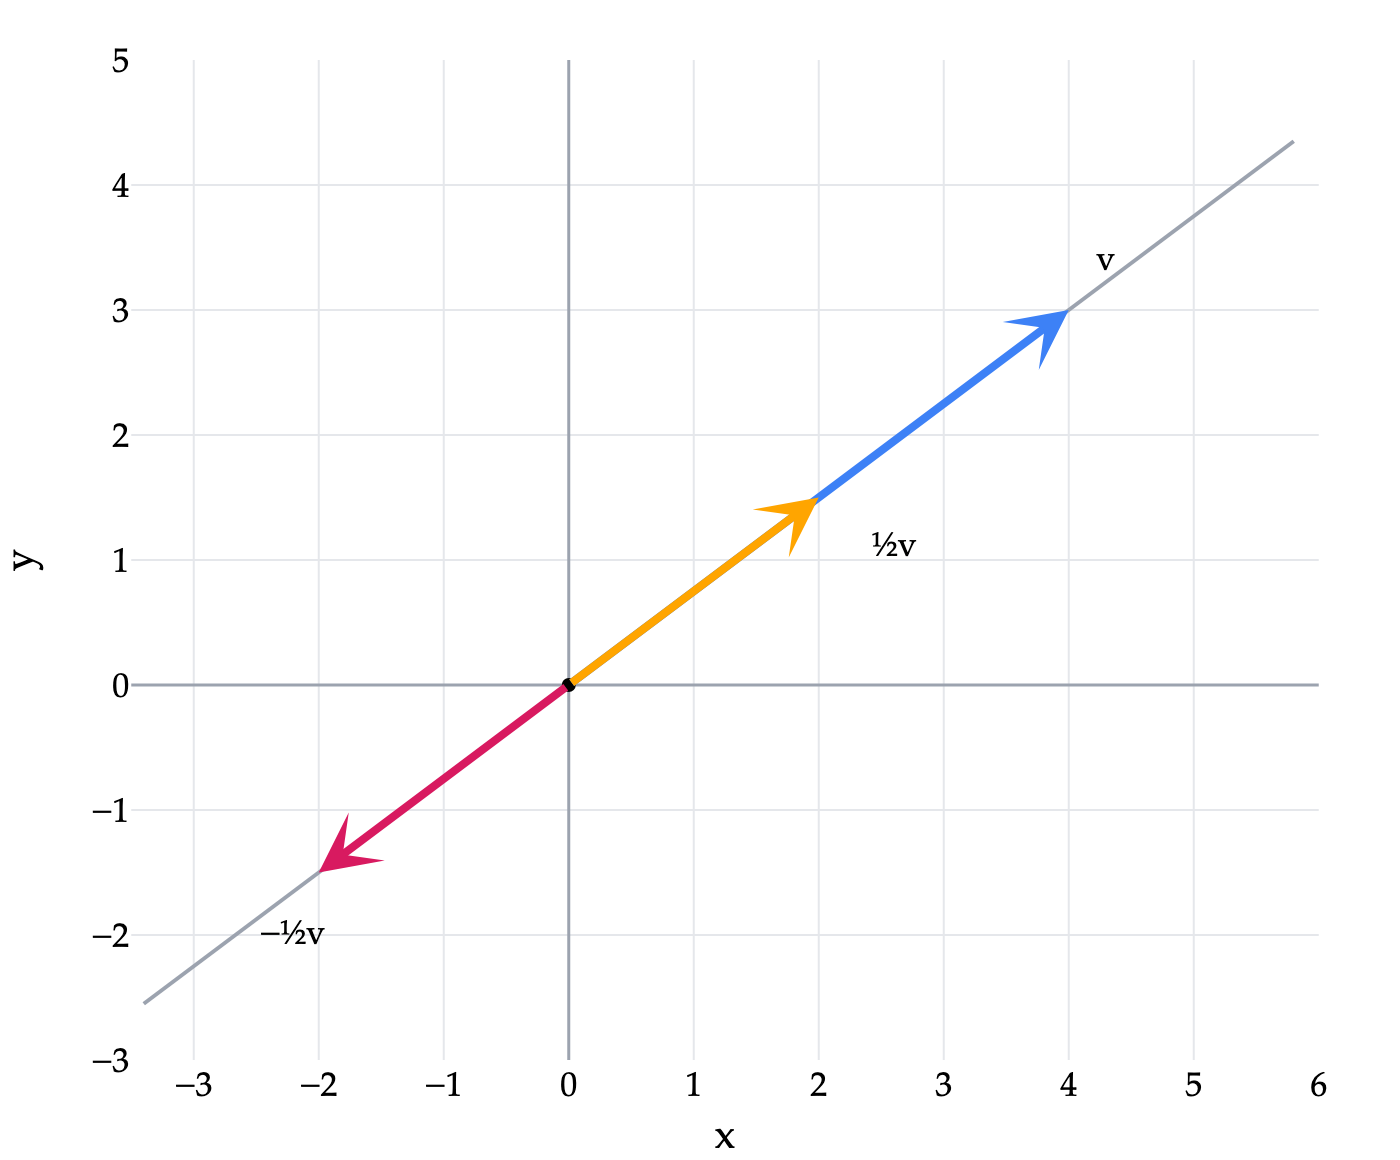

In [5]:
fig=base2((-3.5,6),(-3,5))
line2(fig,(-3.4,-2.55),(5.8,4.35),'#9ca3af')
vec2(fig,(4,3),'v',BLUE,dx=0.3,dy=0.4,width=4)
vec2(fig,(2,1.5),'½v',ORANGE,dx=0.6,dy=-0.4,width=4)
vec2(fig,(-2,-1.5),'−½v',PINK,dx=-0.2,dy=-0.5,width=4)
point2(fig,(0,0))
fig.show(scale=2)

The line $\ell$ through the origin can be described using the vector $\vec v=\begin{bmatrix}4\\3\end{bmatrix}$.

Note that we could have picked any nonzero vector along this line, e.g.

$$
\frac{1}{2}\vec{v} = \begin{bmatrix}
2\\
3/2
\end{bmatrix} \quad \text{or} \quad -\frac{1}{2}\vec{v} = \begin{bmatrix}
-2\\
-3/2
\end{bmatrix} \quad \text{or} \quad \frac{1}{3}\vec{v} = \begin{bmatrix}
4/3\\
1
\end{bmatrix}
$$

Multiplying by a nonzero scalar changes the length, and possibly reverses the direction, as we saw in [Chapter 1.5](../ch01/01-05.ipynb). It does not change the line that the vector spans.

So in this case

$$
\ell=\operatorname{span}(\vec v)=\operatorname{span}(\frac{1}{2}\vec v)
=\operatorname{span}(-\frac{1}{2}\vec v)=\operatorname{span}(\frac{1}{3}\vec v) \quad \text{etc.}
$$

::::{tip} Activity 1

Let $\ell'$ be the span of

$$
\begin{bmatrix}
2\\
1
\end{bmatrix}.
$$

Draw $\ell'$. Give an equation describing $\ell'$.

:::{tip} Solution
:class: dropdown

Notice that the $y$-coordinate of any point on this line is always one half of
the $x$-coordinate. So the equation of the line is

$$
y-\frac12 x=0
$$

or

$$
x-2y=0.
$$

We could multiply the equation by any nonzero number, and that would give an
equally good equation.

For example,

$$
2x-4y=0.
$$

So the equation describing the line is not unique.
:::
::::

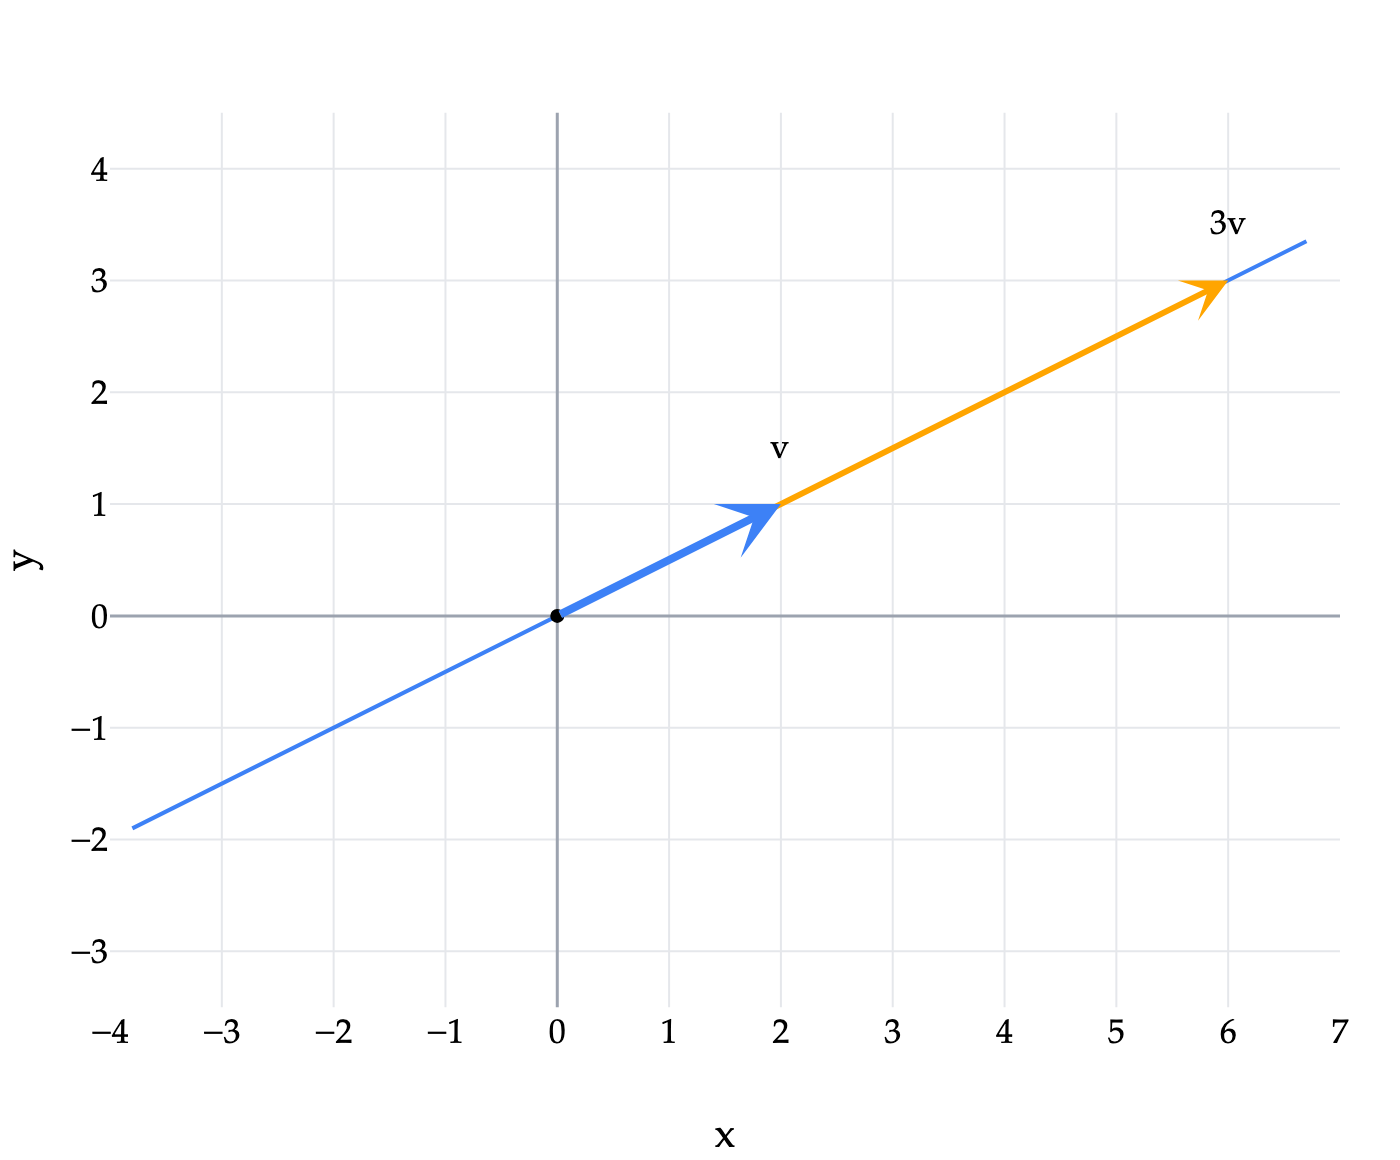

In [6]:
fig=base2((-4,7),(-3.5,4.5))
line2(fig,(-3.8,-1.9),(6.7,3.35))
vec2(fig,(6,3),'3v',ORANGE,dx=0,dy=0.5)
vec2(fig,(2,1),'v',BLUE,dx=0,dy=0.5,width=4)
point2(fig,(0,0))
fig.show(scale=2)

The line $\ell\prime$ spanned by $\vec v=\begin{bmatrix}2\\1\end{bmatrix}$, with $3\vec v=\begin{bmatrix}6\\3\end{bmatrix}$ also shown.

## Normal vectors and line equations

In [Chapter 1.6](../ch01/01-06.ipynb), we learned that two vectors are **orthogonal** exactly when their dot product is zero. We can use that fact to connect a line's equation to its geometry.

Let's reconsider the line

$$
\ell: 3x-4y=0.
$$

Let $\ell^\perp$ be the unique line through the origin that is perpendicular to $\ell$.

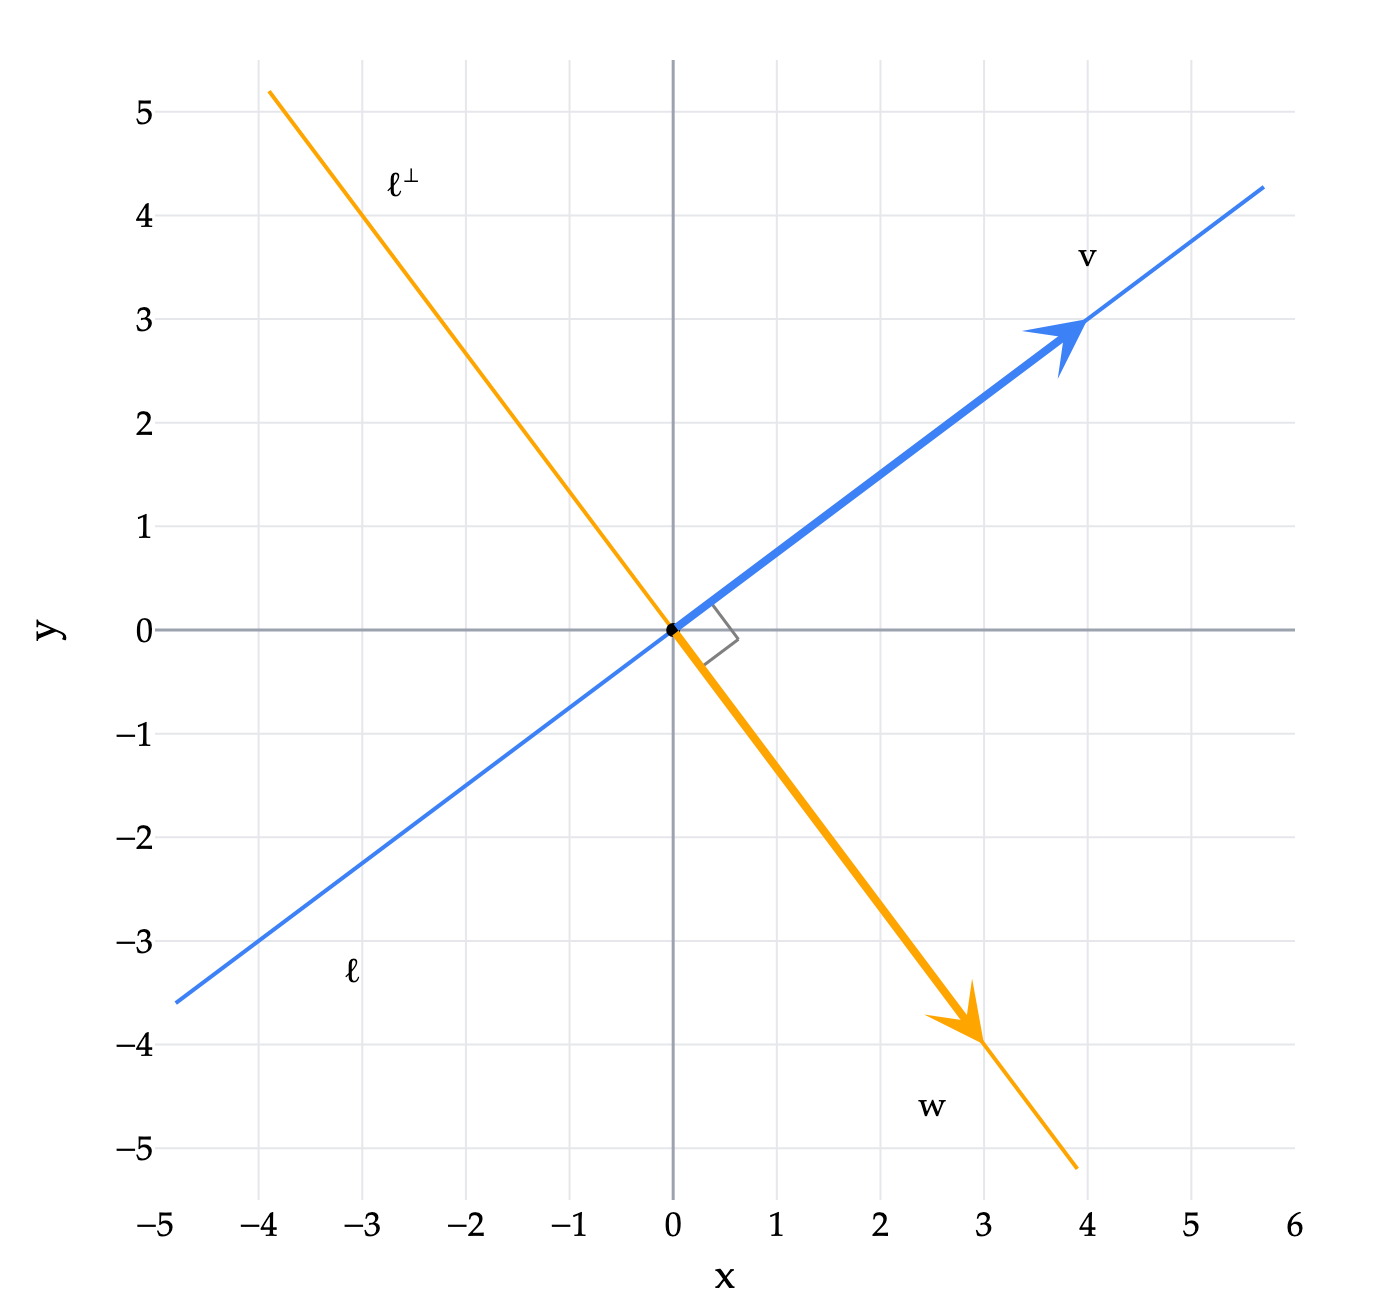

In [7]:
fig=base2((-5,6),(-5.5,5.5),height=650)
line2(fig,(-4.8,-3.6),(5.7,4.275),BLUE)
line2(fig,(-3.9,5.2),(3.9,-5.2),ORANGE)
vec2(fig,(4,3),'v',BLUE,dx=0,dy=0.6,width=4)
vec2(fig,(3,-4),'w',ORANGE,dx=-0.5,dy=-0.6,width=4)
square2(fig,(0,0),(4,3),(3,-4),0.45)
point2(fig,(0,0))
label2(fig,(-3.1,-3.3),'ℓ')
label2(fig,(-2.6,4.3),'ℓ<sup>⊥</sup>')
fig.show(scale=2)

The coefficient vector $\begin{bmatrix}3\\-4\end{bmatrix}$ is perpendicular to the line $3x-4y=0$.

Notice that the coefficients of the equation defining $\ell$ are

$$
\begin{bmatrix}3\\-4\end{bmatrix}.
$$

Let us name the corresponding vector

$$
\begin{bmatrix}
3\\
-4
\end{bmatrix}
=
\vec w.
$$

Notice that $\vec w $
lies on $\ell^\perp$.
What is going on?

We can write

$$
3x-4y=0
$$

as

$$
\begin{bmatrix}
3\\
-4
\end{bmatrix}
\cdot
\begin{bmatrix}
x\\
y
\end{bmatrix}
=0.
$$

So the points on the line $\ell$ are exactly those that are perpendicular to
the vector

$$
\begin{bmatrix}
3\\
-4
\end{bmatrix}.
$$

:::{note} Key idea
A **normal vector** to a line is a nonzero vector perpendicular to its direction.

The coefficients of an equation defining $\ell$ form a nonzero vector on $\ell^\perp$.
:::

So we can think of the line $\ell$ in two different ways:

$$
\ell
=
\operatorname{span}(\vec v),
\qquad
\vec v=
\begin{bmatrix}
4\\
3
\end{bmatrix},
$$

or

$$
\ell
=
\left\{
\text{vectors perpendicular to } \vec w
\right\},
\qquad
\vec w=
\begin{bmatrix}
3\\
-4
\end{bmatrix}.
$$

Likewise, we can think of $\ell^\perp$ as

$$
\ell^\perp
=
\operatorname{span}(\vec w),
\qquad
\vec w=
\begin{bmatrix}
3\\
-4
\end{bmatrix},
$$

or

$$
\ell^\perp
=
\left\{
\text{vectors perpendicular to } \vec v
\right\},
\qquad
\vec v=
\begin{bmatrix}
4\\
3
\end{bmatrix}.
$$

So an equation for $\ell^\perp$ is

$$
4x+3y=0.
$$

**Remark.**

We can pick other vectors that span $\ell^\perp$ eg. 

$$
\ell^\perp = \operatorname{span} (3\vec{w}),
$$

where 

$$
3\vec{w} =\begin{bmatrix}
9\\
-12
\end{bmatrix}
$$

This means another way of describing
$\ell$ is the equation

$$
9x - 12y=0
$$

.
This just corresponds to multiplying the original equation we had by the scalar $3$.

::::{tip} Activity 2

Consider the line

$$
\ell'=\operatorname{span}
\begin{bmatrix}
2\\
1
\end{bmatrix}.
$$

1. Draw $\ell'$ and $(\ell')^\perp$.
1. Find a nonzero vector on $(\ell')^\perp$.
1. Use your vector from the previous subpart to write an equation for $\ell'$.
1. Find another nonzero vector on $(\ell')^\perp$.
1. Use your vector from the previous subpart to write another equation for $\ell'$.
1. How do your equations for $\ell'$ differ?
1. Write down an equation for $(\ell')^\perp$.

:::{tip} Solution
:class: dropdown

The line $\ell'$ has slope $1/2$, and its perpendicular line has slope $-2$.

A nonzero vector on $(\ell')^\perp$ is $\begin{bmatrix}1\\-2\end{bmatrix}$, giving the equation $x-2y=0$ for $\ell'$. Another is $\begin{bmatrix}2\\-4\end{bmatrix}$, giving $2x-4y=0$. The second equation is twice the first, so they have the same solution set.

An equation for $(\ell')^\perp$ is $2x+y=0$, using $\begin{bmatrix}2\\1\end{bmatrix}$ as its normal vector.
:::
::::

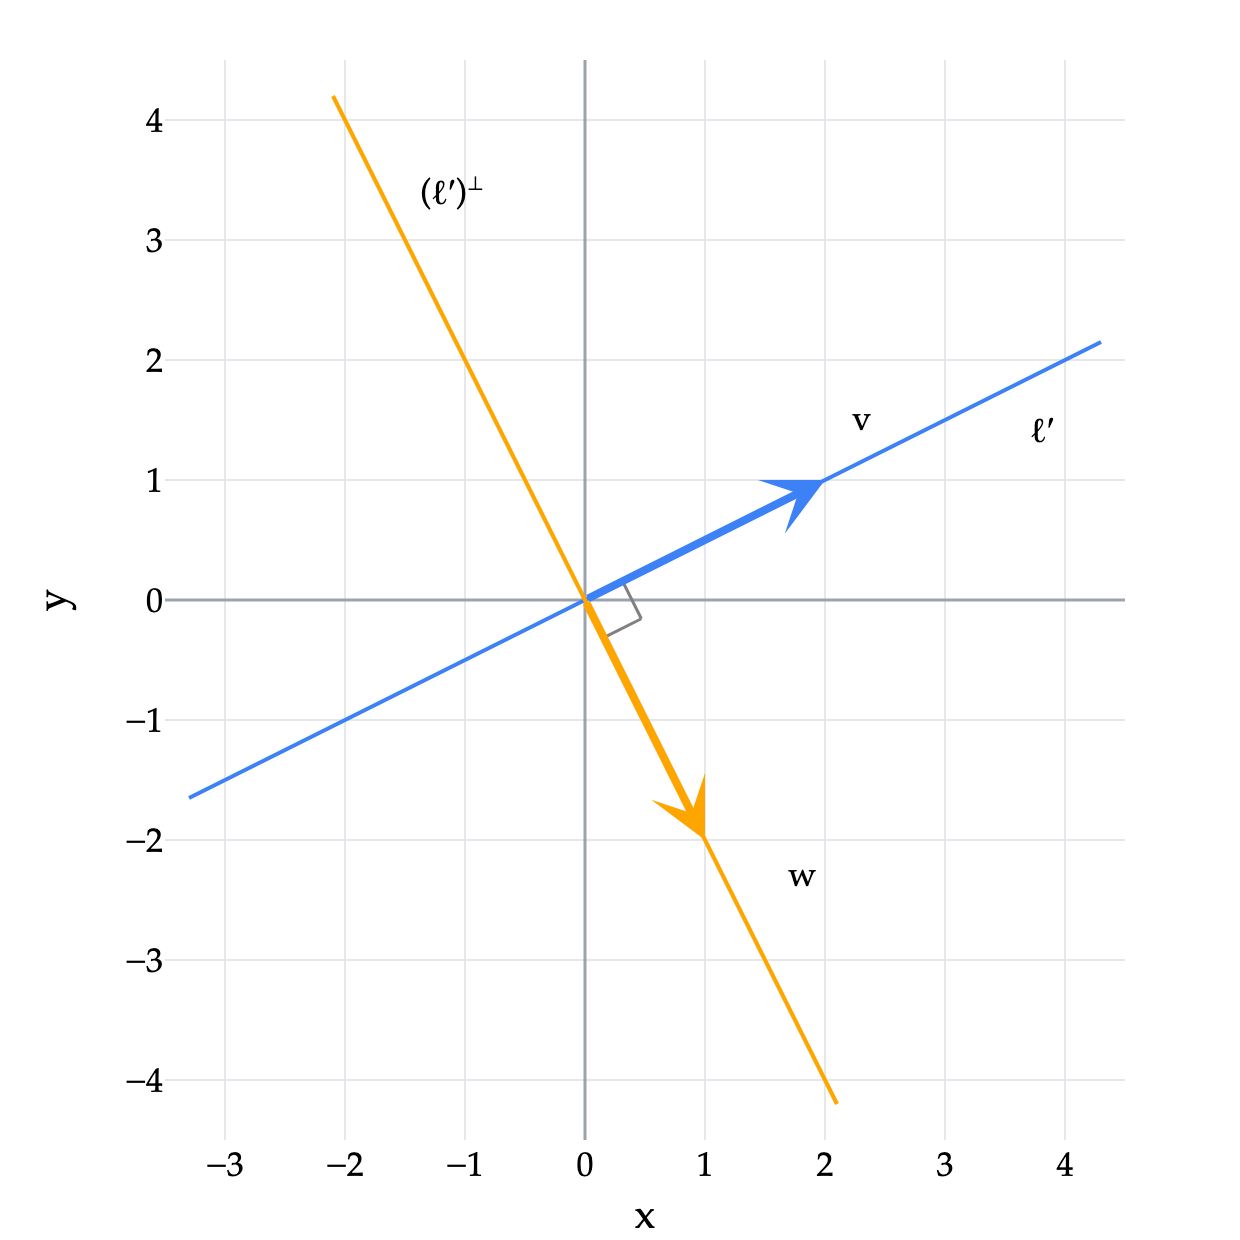

In [8]:
fig=base2((-3.5,4.5),(-4.5,4.5),width=620,height=620)
line2(fig,(-3.3,-1.65),(4.3,2.15),BLUE)
line2(fig,(-2.1,4.2),(2.1,-4.2),ORANGE)
vec2(fig,(2,1),'v',BLUE,dx=0.3,dy=0.5,width=4)
vec2(fig,(1,-2),'w',ORANGE,dx=0.8,dy=-0.3,width=4)
square2(fig,(0,0),(2,1),(1,-2),0.35)
label2(fig,(3.8,1.4),'ℓ′')
label2(fig,(-1.1,3.4),'(ℓ′)<sup>⊥</sup>')
fig.show(scale=2)

The line $\ell\prime$ and its perpendicular line $(\ell\prime)^\perp$, with $\vec v=\begin{bmatrix}2\\1\end{bmatrix}$ and $\vec w=\begin{bmatrix}1\\-2\end{bmatrix}$.

## Affine lines

Now we can discuss lines that don't necessarily pass through the origin. These
are often called affine lines to indicate that they need not pass through the
origin.

In [Chapter 1.4](../ch01/01-04.ipynb), we saw that a vector represents a displacement and can be drawn from any starting point. Here, we use that idea to shift an entire line.

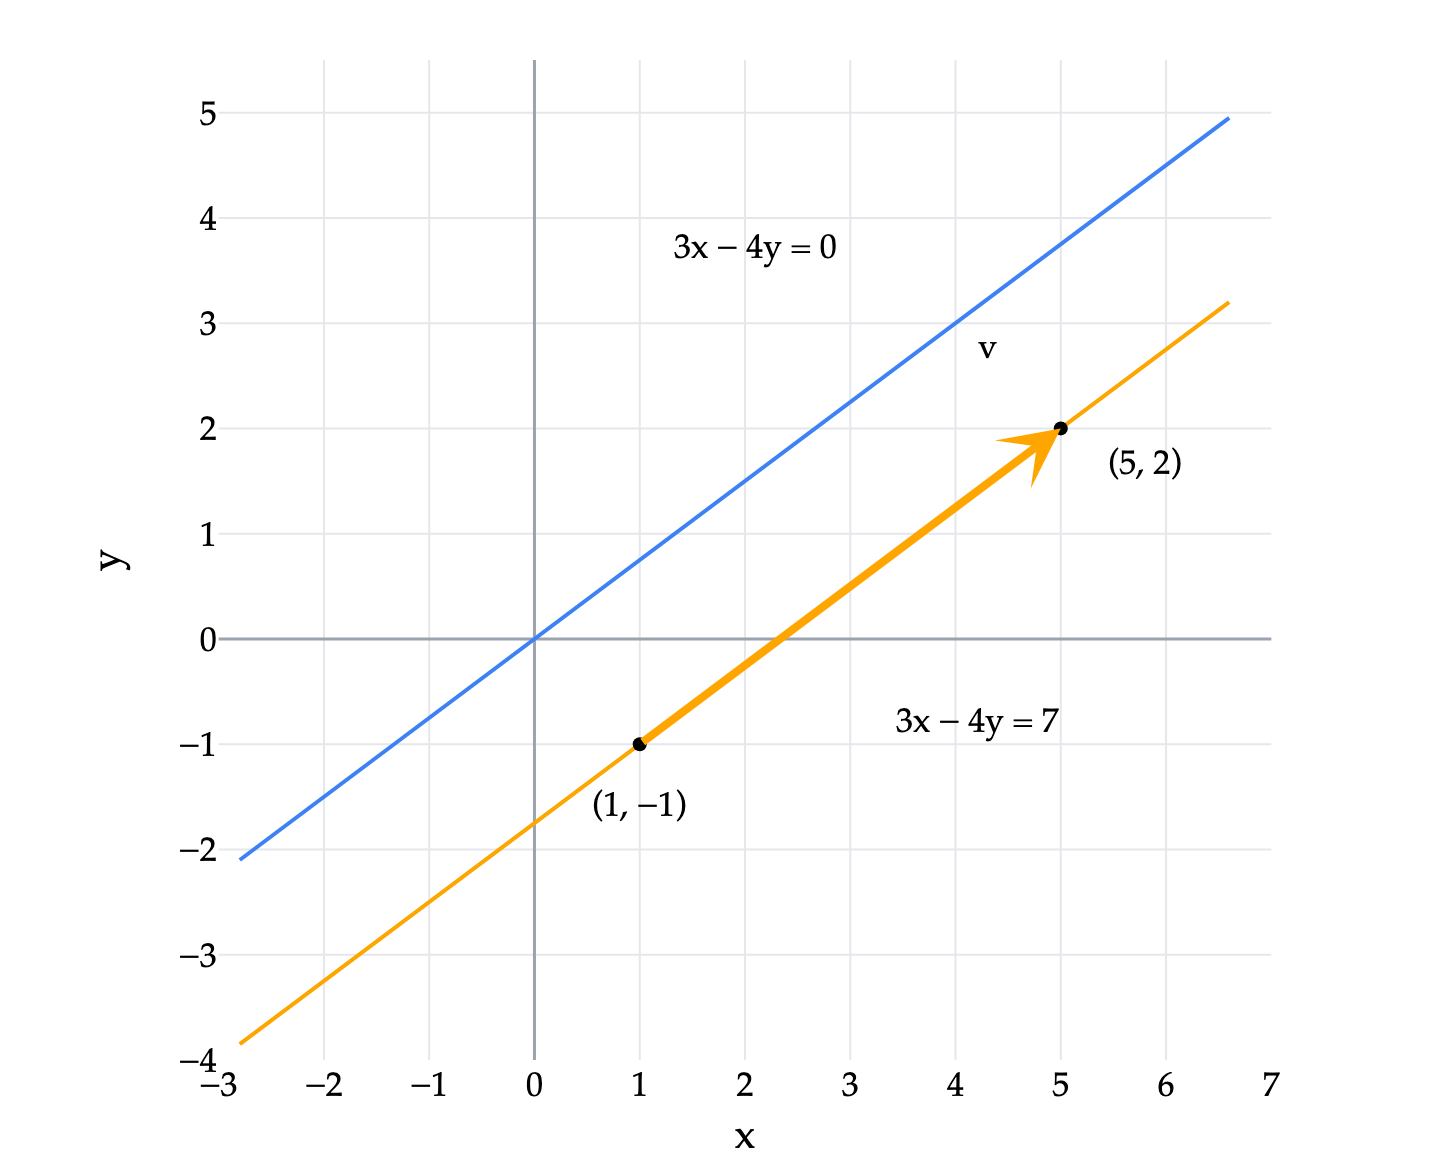

In [9]:
fig=base2((-3,7),(-4,5.5),width=720)
line2(fig,(-2.8,-2.1),(6.6,4.95),BLUE)
line2(fig,(-2.8,-3.85),(6.6,3.2),ORANGE)
vec2(fig,(5,2),'v',ORANGE,start=(1,-1),dx=-0.7,dy=0.75,width=4)
point2(fig,(1,-1),'(1, −1)',dx=0,dy=-0.6)
point2(fig,(5,2),'(5, 2)',dx=0.8,dy=-0.35)
label2(fig,(2.1,3.7),'3x − 4y = 0')
label2(fig,(4.2,-0.8),'3x − 4y = 7')
fig.show(scale=2)

The affine line $3x-4y=7$ is parallel to the homogeneous line $3x-4y=0$.

Let's consider the line

$$
3x-4y=7.
$$

Notice the point

$$
(1,-1)
$$

lies on it.

We can get any point on this line by first going to

$$
\begin{bmatrix}
1\\
-1
\end{bmatrix}
$$

then adding any vector on $\ell$ to it.

For this line, we may take

$$
\vec v=
\begin{bmatrix}
4\\
3
\end{bmatrix},
$$

since this vector points in the same direction as the line $3x-4y=0$.

So the line $3x-4y=7$ is

$$
\begin{bmatrix}
1\\
-1
\end{bmatrix}
+
\operatorname{span}(\vec v)
=
\left\{
\begin{bmatrix}
1\\
-1
\end{bmatrix}
+
t\vec v
\;:\;
t\in\mathbb{R}
\right\}.
$$

Instead of

$$
\begin{bmatrix}
1\\
-1
\end{bmatrix},
$$

we could have taken any point on the line, e.g.

$$
\begin{bmatrix}
5\\
2
\end{bmatrix},
$$

so

$$
3x-4y=7
$$

can also be written as

$$
\left\{
\begin{bmatrix}
5\\
2
\end{bmatrix}
+
t\vec v
\;:\;
t\in\mathbb{R}
\right\}.
$$

**Summary.**

Affine lines in $\mathbb{R}^2$ may be thought of as translations of the span
of a vector by some fixed vector.

::::{tip} Activity 3

Can you describe affine lines using a normal vector and a dot product?

:::{tip} Solution
:class: dropdown

They can be described as a set of vectors $\vec{v'}$ such that

$$
\vec{v'}\cdot \vec w
$$

is a fixed constant, where $\vec w$ is a nonzero vector on $\ell^\perp$.

For example, the affine line

$$
3x-4y=7
$$

can be written as

$$
\begin{bmatrix}
3\\
-4
\end{bmatrix}
\cdot
\begin{bmatrix}
x\\
y
\end{bmatrix}
=7.
$$

So it is the set of all points whose dot product with the fixed normal vector

$$
\begin{bmatrix}
3\\
-4
\end{bmatrix}
$$

is the fixed constant $7$.
:::
::::